# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [2]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd
import statsmodels.api as sm

# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
import matplotlib.font_manager
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import scale

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [3]:
df = pd.read_csv('data/nndb_flat.csv')
df

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8613,83110,Finfish and Shellfish Products,"MACKEREL,SALTED","Fish, mackerel, salted",NaN,NaN,NaN,305.0,18.50,25.10,...,0.0375,0.206250,0.146154,0.016667,0.055000,0.000111,0.142857,0.362857,1.334545,0.100000
8614,90240,Finfish and Shellfish Products,"SCALLOP,(BAY&SEA),CKD,STMD","Mollusks, scallop, (bay and sea), cooked, steamed",NaN,NaN,NaN,111.0,20.54,0.84,...,0.0500,0.067250,0.018462,0.010000,0.008333,0.000037,0.088095,0.608571,0.394545,0.140909
8615,90480,Sweets,"SYRUP,CANE","Syrup, Cane",NaN,NaN,NaN,269.0,0.00,0.00,...,0.0000,0.006250,0.046154,0.108333,0.010833,0.000022,0.023810,0.011429,0.012727,0.017273
8616,90560,Finfish and Shellfish Products,"SNAIL,RAW","Mollusks, snail, raw",NaN,NaN,NaN,90.0,16.10,1.40,...,0.0150,0.087500,0.092308,0.008333,0.008333,0.000444,0.595238,0.388571,0.498182,0.090909


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [7]:
# Selecciona solo las columnas numéricas (int, float)
df_numerico = df.select_dtypes(include=['number'])
df_numerico.corr()

,ID,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
ID,1.000000,0.126126,0.075538,-0.011996,0.177297,0.082710,0.008252,-0.031211,-0.060463,0.016512,...,-0.051166,0.010387,-0.024343,0.011311,-0.050720,-0.003765,-0.001867,0.045925,0.011775,0.009195
Energy_kcal,0.126126,1.000000,0.110302,0.806795,0.487096,0.313151,0.197338,0.026329,0.121872,-0.012292,...,0.145936,0.174991,0.155830,0.187439,0.123571,0.099513,0.255880,0.195181,0.056673,0.112766
Protein_g,0.075538,0.110302,1.000000,0.054715,-0.301974,-0.266170,-0.072777,0.026483,0.228485,0.245423,...,0.008939,0.376939,0.202480,0.098360,0.046888,0.158900,0.218611,0.444608,0.378369,0.416315
Fat_g,-0.011996,0.806795,0.054715,1.000000,-0.054116,-0.001962,-0.028842,0.024379,-0.046950,-0.020786,...,-0.058049,-0.022671,-0.036286,-0.005785,0.015039,0.042765,0.070781,0.066086,0.037559,0.028264
Carb_g,0.177297,0.487096,-0.301974,-0.054116,1.000000,0.615344,0.458192,0.001871,0.195571,-0.094636,...,0.325170,0.173285,0.232408,0.281809,0.189106,0.062106,0.287207,0.073180,-0.114600,-0.012187
Sugar_g,0.082710,0.313151,-0.266170,-0.001962,0.615344,1.000000,0.115916,0.010143,0.088767,-0.050450,...,0.161257,0.034378,0.125225,0.097751,0.129540,-0.005837,0.041308,-0.049784,-0.123708,-0.021991
Fiber_g,0.008252,0.197338,-0.072777,-0.028842,0.458192,0.115916,1.000000,0.005910,0.242804,-0.052045,...,0.249075,0.135257,0.157703,0.205211,0.232286,0.185044,0.542038,0.158422,-0.035897,0.085154
VitA_mcg,-0.031211,0.026329,0.026483,0.024379,0.001871,0.010143,0.005910,1.000000,0.136605,0.581004,...,0.108517,0.151679,0.325709,0.052921,0.034822,0.569945,0.024572,0.055814,0.048043,0.070541
VitB6_mg,-0.060463,0.121872,0.228485,-0.046950,0.195571,0.088767,0.242804,0.136605,1.000000,0.264325,...,0.550087,0.714143,0.581678,0.417011,0.177268,0.116326,0.293169,0.213395,0.109004,0.447143
VitB12_mcg,0.016512,-0.012292,0.245423,-0.020786,-0.094636,-0.050450,-0.052045,0.581004,0.264325,1.000000,...,0.158483,0.279033,0.436182,0.099601,0.011715,0.570642,0.004124,0.148774,0.215308,0.298136


las columnas USRDA son un derivado de su versión en gramos

### Variables no numéricas
Elimina las variables de texto del dataset

In [10]:
cols_a_mantener = [col for col in df_numerico.columns if not col.endswith('USRDA') and col != 'ID']
df_limpio = df_numerico[cols_a_mantener]

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

In [11]:
df_log = np.log1p(df_limpio)

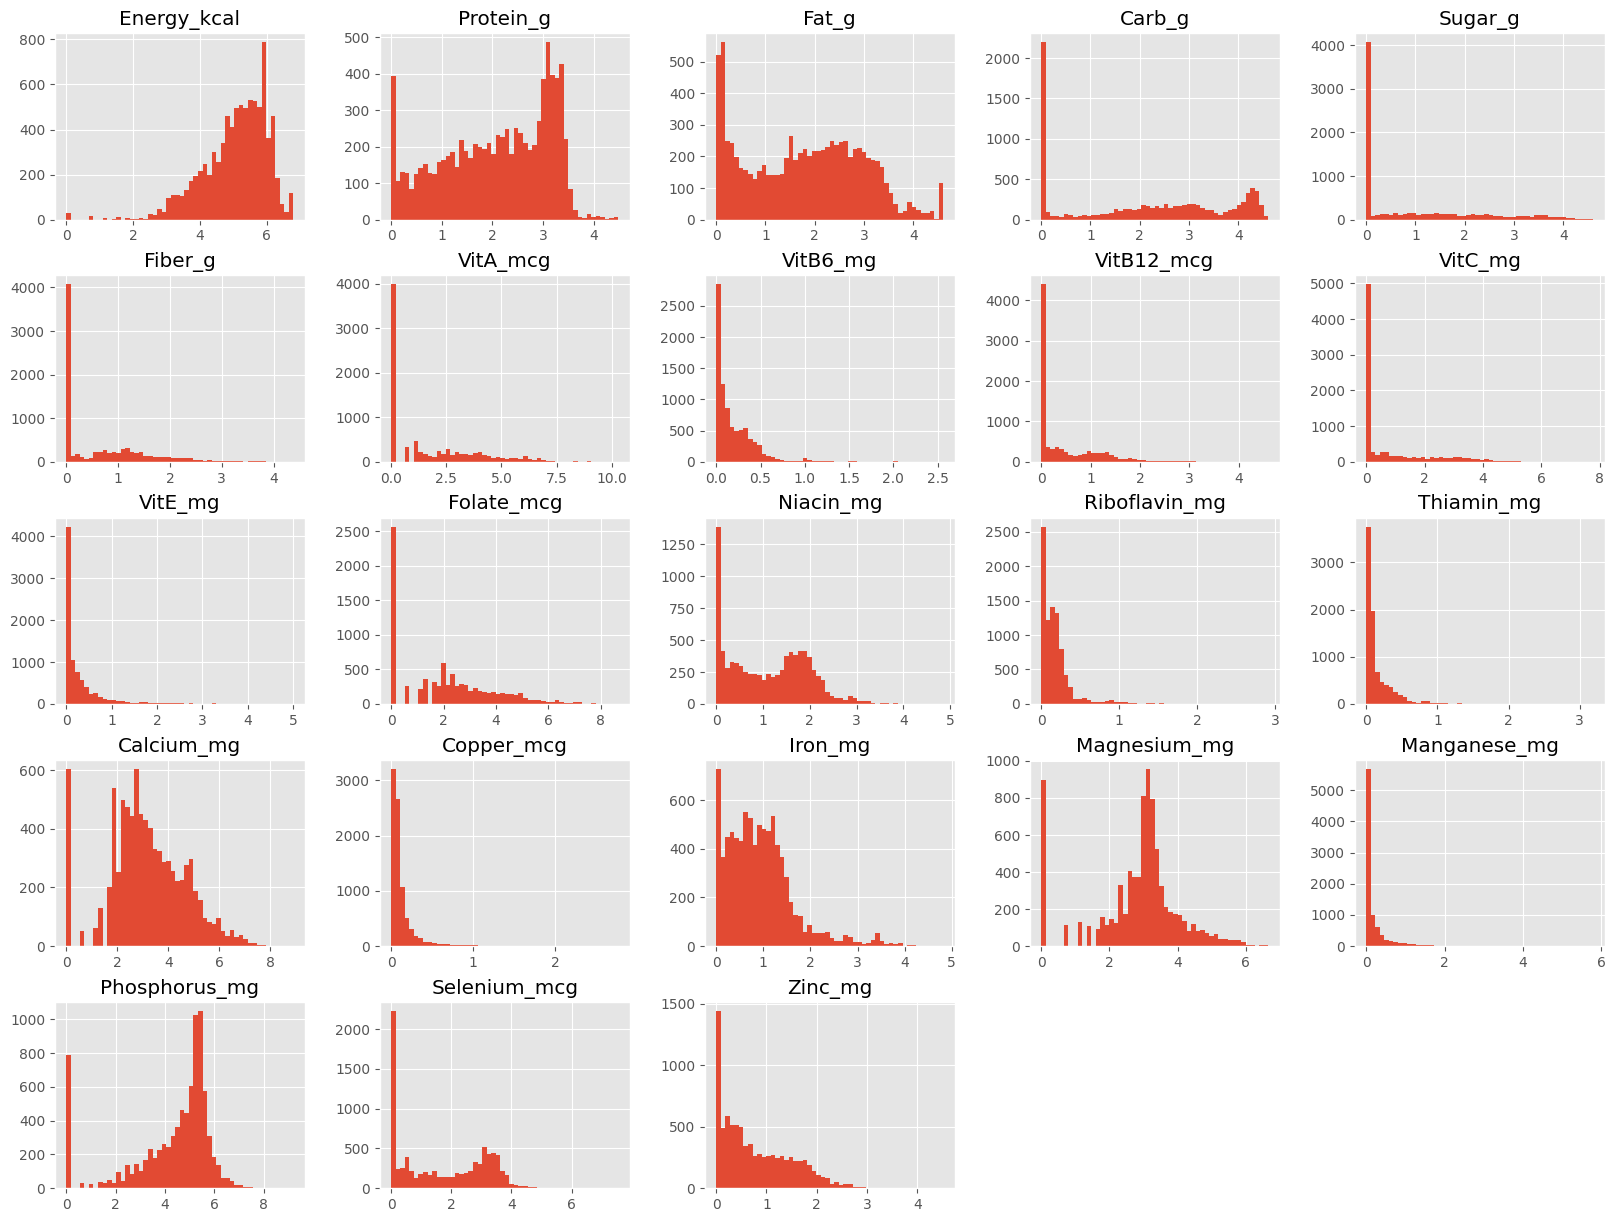

In [24]:
df_log.hist(bins=50, figsize=(20,15))
plt.show()

### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [23]:
scaled = StandardScaler().fit_transform(df_log)
df_scaled = pd.DataFrame(scaled, columns=df_log.columns)

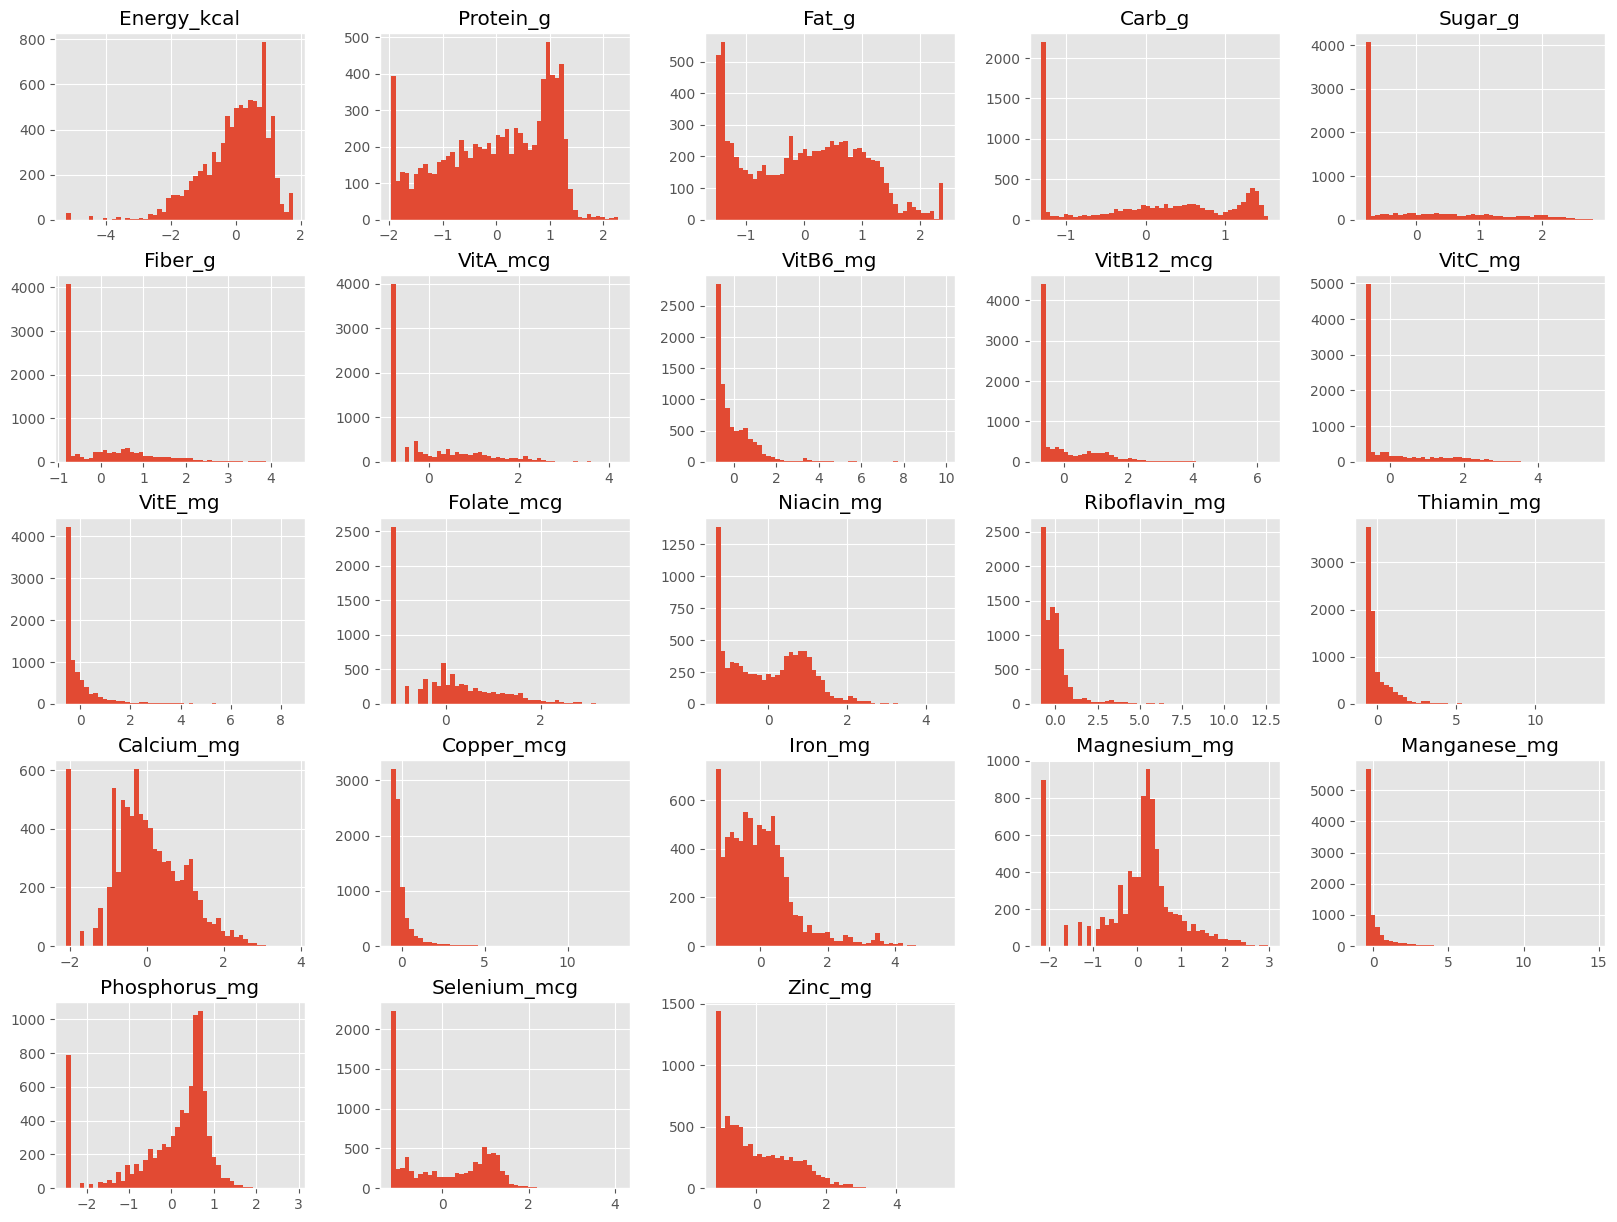

In [28]:
df_scaled.hist(bins=50, figsize=(20,15))
plt.show()

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [39]:
n_componentes = df_scaled.shape[1]
pca = PCA(n_components=n_componentes)
componentes_pca = pca.fit_transform(df_scaled)

### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

In [38]:
# Varianza explicada por cada componente
varianza_explicada = pca.explained_variance_ratio_

# Varianza explicada acumulada
varianza_acumulada = np.cumsum(varianza_explicada)

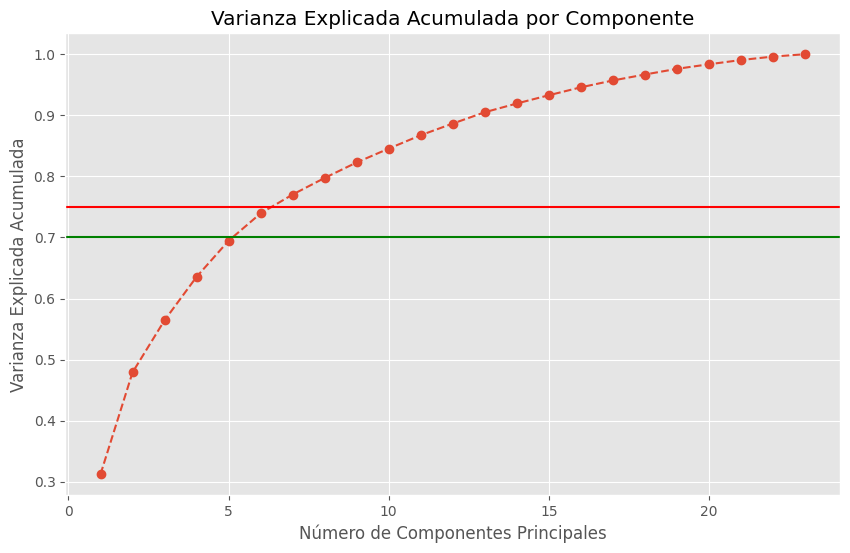

In [40]:
plt.figure(figsize=(10, 6))
plt.plot(range(1, n_componentes + 1), varianza_acumulada, marker='o', linestyle='--')
plt.axhline(y=0.75, color='r', linestyle='-') # Línea al 75%
plt.axhline(y=0.70, color='g', linestyle='-') # Línea al 70%
plt.title('Varianza Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes Principales')
plt.ylabel('Varianza Explicada Acumulada')
plt.grid(True)
plt.show()

In [41]:
n_comp_75 = np.argmax(varianza_acumulada >= 0.75) + 1
print(f"Componentes necesarios para alcanzar el 75% de varianza: {n_comp_75}")

Componentes necesarios para alcanzar el 75% de varianza: 7


## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [45]:
pca_final = PCA(n_components=n_comp_75)
df_pca_final = pca_final.fit_transform(df_scaled)

In [46]:
columnas_pca = [f'PC{i+1}' for i in range(n_comp_75)]
df_resultado = pd.DataFrame(df_pca_final, columns=columnas_pca)

In [47]:
# Unimos de nuevo la columna 'FoodGroup' original para poder analizar después
# Asegúrate de que los índices coincidan
df_resultado['FoodGroup'] = df['FoodGroup'].values

In [49]:
print(f"Nuevo shape del dataset: {df_resultado.shape}")
df_resultado

Nuevo shape del dataset: (8618, 8)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,FoodGroup
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222,0.151252,Dairy and Egg Products
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613,0.212474,Dairy and Egg Products
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607,0.441633,Dairy and Egg Products
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054,0.487040,Dairy and Egg Products
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876,0.797944,Dairy and Egg Products
...,...,...,...,...,...,...,...,...
8613,2.553661,-2.548700,-0.472185,-0.109428,2.716513,0.018570,-0.233604,Finfish and Shellfish Products
8614,0.075018,-1.840922,-0.935725,-1.348908,-0.392092,-0.759672,-0.429117,Finfish and Shellfish Products
8615,-2.930529,1.664405,1.242070,1.172396,-0.915550,-0.885902,0.980484,Sweets
8616,1.118895,-0.780834,-0.805126,-1.581838,1.641702,1.090002,-0.871438,Finfish and Shellfish Products


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [50]:
# Función auxiliar para obtener los top 3 grupos por componente
def get_top_groups(df, component_col, n=3):
    return df.groupby('FoodGroup')[component_col].mean().nlargest(n)

# Iterar sobre los componentes creados
for col in columnas_pca:
    print(f"\n--- Top 3 Grupos para {col} ---")
    top_groups = get_top_groups(df_resultado, col)
    print(top_groups)


--- Top 3 Grupos para PC1 ---
FoodGroup
Breakfast Cereals        4.020261
Nut and Seed Products    3.120684
Spices and Herbs         2.562117
Name: PC1, dtype: float64

--- Top 3 Grupos para PC2 ---
FoodGroup
Spices and Herbs         3.647736
Breakfast Cereals        2.748076
Nut and Seed Products    2.267573
Name: PC2, dtype: float64

--- Top 3 Grupos para PC3 ---
FoodGroup
Fats and Oils            2.333724
Baked Products           1.727793
Nut and Seed Products    1.241486
Name: PC3, dtype: float64

--- Top 3 Grupos para PC4 ---
FoodGroup
Breakfast Cereals    2.265027
Fats and Oils        1.045026
Beverages            0.545486
Name: PC4, dtype: float64

--- Top 3 Grupos para PC5 ---
FoodGroup
Fats and Oils             2.634166
Dairy and Egg Products    1.555680
Baby Foods                0.929960
Name: PC5, dtype: float64

--- Top 3 Grupos para PC6 ---
FoodGroup
Fats and Oils            2.054032
Nut and Seed Products    1.762298
Spices and Herbs         1.461075
Name: PC6, dtype: flo